# DRR Data Augmentation (local test)

Augmentation for the bi-planar DRRs generated by `drr_generation.ipynb` (256x256 float32,
range `[0, 1]`, saved under `data/interim/DRRs/{healthy,fractured}/{case}/{side}/{ap,lat}.npy`).

**Augmentations** (subtle strength):

| Augmentation | Setting | Purpose |
|---|---|---|
| Rotation | +-5 deg | micro limb misalignment / orientation variation |
| Horizontal flip | left<->right mirror | simulate contralateral knee anatomy, orientation diversity |
| Gaussian noise | sigma ~ 0.01-0.03 | low-dose X-ray graininess |
| Brightness / contrast | brightness +-10%, contrast 0.9-1.1x | different X-ray machine settings |

This notebook (1) shows each augmentation in isolation, (2) shows a combined random
pipeline, and (3) saves the **full combinatorial grid** of variants per knee
(flip x rotation x noise x brightness-contrast) to
`data/processed/augmented_DRRs/{dataset}/{case}/{side}/{variant}/` to maximize the number
of training permutations, plus a metadata CSV.

> **Note - geometric vs photometric variants.** This is a 2D operation on DRRs only. For the
> 3D reconstruction task the target is a 3D CT volume; **geometric** augmentations (rotation,
> flip) on the 2D *input* must be matched by the same transform on the 3D target, or
> input<->target will not align. Each saved variant is tagged `geometric=True/False` in the
> metadata so the training loader knows which variants need the GT volume transformed.
> **Photometric** variants (noise / brightness-contrast only) pair directly with the
> existing GT.

## Imports

NumPy / SciPy / imageio / matplotlib only - no DiffDRR or torch needed for augmentation.

In [1]:
import numpy as np
import pandas as pd
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import itertools
import shutil
from pathlib import Path
from scipy.ndimage import rotate as ndi_rotate
from loguru import logger
from tqdm import tqdm

import scipy
print("numpy", np.__version__, "| scipy", scipy.__version__)

numpy 2.4.2 | scipy 1.17.1


## Configuration

Paths and augmentation strength. The output mirrors the DRR folder layout. A seeded RNG
makes the visuals reproducible. DRRs are float32 in `[0, 1]`, so all strengths are on that
scale.

In [2]:
# ---- Configuration ----
PROJECT_ROOT = Path(r"c:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject")
DRR_DIR      = PROJECT_ROOT / "data" / "interim"  / "DRRs"
AUG_OUT_DIR  = PROJECT_ROOT / "data" / "processed" / "augmented_DRRs"
AUG_OUT_DIR.mkdir(parents=True, exist_ok=True)

# Reproducibility
SEED = 42
rng  = np.random.default_rng(SEED)

# Augmentation strength (subtle). DRRs are float32 in [0, 1].
ROT_DEG        = 5.0           # +- rotation in degrees (micro limb misalignment)
NOISE_SIGMA    = (0.01, 0.03)  # Gaussian noise std range (low-dose X-ray graininess)
BRIGHT_DELTA   = 0.10          # +- additive brightness (machine exposure)
CONTRAST_RANGE = (0.9, 1.1)    # multiplicative contrast about the image mean
HFLIP_PROB     = 0.5           # horizontal flip probability in the combined pipeline

logger.info(f"DRR in  -> {DRR_DIR}")
logger.info(f"aug out -> {AUG_OUT_DIR}")

2026-06-06 16:01:15.339 | INFO     | __main__:<module>:18 - DRR in  -> c:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject\data\interim\DRRs


2026-06-06 16:01:15.341 | INFO     | __main__:<module>:19 - aug out -> c:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject\data\processed\augmented_DRRs


## Augmentation functions

One small function per augmentation (each takes and returns a float32 image clipped to
`[0, 1]`), plus `augment_pipeline`, which samples all four at random - this is what the
training data loader would call per sample.

In [3]:
def _clip01(img: np.ndarray) -> np.ndarray:
    """Clip to the valid DRR range and keep float32."""
    return np.clip(img, 0.0, 1.0).astype(np.float32)


def aug_rotate(img: np.ndarray, deg: float) -> np.ndarray:
    """Rotate by `deg` degrees about the image centre (reshape=False keeps 256x256).
    Bilinear interpolation; corners exposed by the rotation are filled with 0 (air)."""
    out = ndi_rotate(img, deg, reshape=False, order=1, mode="constant", cval=0.0)
    return _clip01(out)


def aug_hflip(img: np.ndarray) -> np.ndarray:
    """Mirror left<->right (simulates the contralateral knee)."""
    return np.fliplr(img).copy().astype(np.float32)


def aug_gaussian_noise(img: np.ndarray, sigma: float, rng: np.random.Generator) -> np.ndarray:
    """Add zero-mean Gaussian noise of std `sigma` (low-dose X-ray graininess)."""
    out = img + rng.normal(0.0, sigma, size=img.shape)
    return _clip01(out)


def aug_brightness_contrast(img: np.ndarray, bright: float, contrast: float) -> np.ndarray:
    """Scale contrast about the image mean, then shift brightness (machine settings).
    new = mean + (img - mean) * contrast + bright."""
    m = float(img.mean())
    out = m + (img - m) * contrast + bright
    return _clip01(out)


def augment_pipeline(img: np.ndarray, rng: np.random.Generator):
    """Apply all four augmentations with randomly sampled parameters.
    Returns (augmented_image, params_dict) - what training would call per sample."""
    deg      = float(rng.uniform(-ROT_DEG, ROT_DEG))
    do_flip  = bool(rng.random() < HFLIP_PROB)
    sigma    = float(rng.uniform(*NOISE_SIGMA))
    bright   = float(rng.uniform(-BRIGHT_DELTA, BRIGHT_DELTA))
    contrast = float(rng.uniform(*CONTRAST_RANGE))

    out = aug_rotate(img, deg)
    if do_flip:
        out = aug_hflip(out)
    out = aug_gaussian_noise(out, sigma, rng)
    out = aug_brightness_contrast(out, bright, contrast)

    params = {"deg": round(deg, 2), "flip": do_flip, "sigma": round(sigma, 3),
              "bright": round(bright, 3), "contrast": round(contrast, 3)}
    return out, params

## Load helpers & test cases

Reuses the case-walk from `drr_generation.ipynb`. `TEST_CASES` is the same set of knees as
the DRR local test, filtered to those actually present on disk so the cells do not crash if
a case is missing.

In [4]:
def collect_all_cases(drr_dir: Path):
    """All (dataset, case, side) tuples that have both ap.npy and lat.npy, sorted.
    Same walk as drr_generation.ipynb's collect_all_drr_cases."""
    cases = []
    for dataset in ["healthy", "fractured"]:
        dset_dir = drr_dir / dataset
        if not dset_dir.exists():
            continue
        for case_dir in sorted(dset_dir.iterdir()):
            if not case_dir.is_dir():
                continue
            for side_dir in sorted(case_dir.iterdir()):
                if not side_dir.is_dir():
                    continue
                if (side_dir / "ap.npy").exists() and (side_dir / "lat.npy").exists():
                    cases.append((dataset, case_dir.name, side_dir.name))
    return cases


def load_pair(dataset: str, case: str, side: str):
    """Load the AP and LAT DRRs (float32 [0,1]) for one knee."""
    base = DRR_DIR / dataset / case / side
    ap  = np.load(base / "ap.npy").astype(np.float32)
    lat = np.load(base / "lat.npy").astype(np.float32)
    return ap, lat


# Same knees used in drr_generation.ipynb's local test, filtered to what's on disk.
_WANTED = [
    ("healthy",   "VSD_001",  "left"),
    ("healthy",   "VSD_001",  "right"),
    ("healthy",   "VSD_z061", "left"),
    ("healthy",   "VSD_z061", "right"),
    ("fractured", "Case1",    "left"),
    ("fractured", "Case8",    "right"),
]
_available = set(collect_all_cases(DRR_DIR))
TEST_CASES = [c for c in _WANTED if c in _available]
logger.info(f"{len(TEST_CASES)}/{len(_WANTED)} test knees found on disk")
for c in TEST_CASES:
    print(" ", "/".join(c))

2026-06-06 16:01:15.484 | INFO     | __main__:<module>:39 - 6/6 test knees found on disk


  healthy/VSD_001/left
  healthy/VSD_001/right
  healthy/VSD_z061/left
  healthy/VSD_z061/right
  fractured/Case1/left
  fractured/Case8/right


## 1. Each augmentation in isolation

Apply each augmentation on its own to one representative DRR so its individual effect can be
checked. The printed stats confirm values stay within `[0, 1]` and structure is preserved.

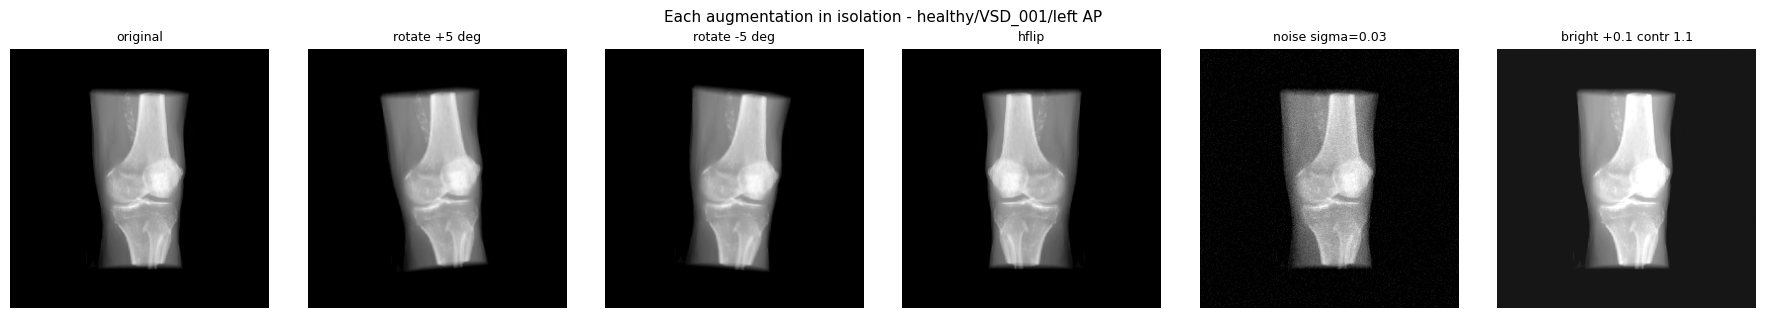

original                 mu=0.132  sigma=0.259  min=0.000  max=1.000
rotate +5 deg            mu=0.132  sigma=0.259  min=0.000  max=0.990
rotate -5 deg            mu=0.132  sigma=0.259  min=0.000  max=0.990
hflip                    mu=0.132  sigma=0.259  min=0.000  max=1.000
noise sigma=0.03         mu=0.141  sigma=0.255  min=0.000  max=1.000
bright +0.1 contr 1.1    mu=0.230  sigma=0.281  min=0.087  max=1.000


In [5]:
# Representative DRR: first available test knee, AP view.
_d, _c, _s = TEST_CASES[0]
base_ap, _ = load_pair(_d, _c, _s)

panels = [
    ("original",            base_ap),
    ("rotate +5 deg",       aug_rotate(base_ap, +ROT_DEG)),
    ("rotate -5 deg",       aug_rotate(base_ap, -ROT_DEG)),
    ("hflip",               aug_hflip(base_ap)),
    ("noise sigma=0.03",    aug_gaussian_noise(base_ap, 0.03, rng)),
    ("bright +0.1 contr 1.1", aug_brightness_contrast(base_ap, 0.10, 1.1)),
]

fig, axes = plt.subplots(1, len(panels), figsize=(3 * len(panels), 3.2))
for ax, (title, im) in zip(axes, panels):
    ax.imshow(im, cmap="gray", vmin=0.0, vmax=1.0)
    ax.set_title(title, fontsize=9)
    ax.axis("off")
fig.suptitle(f"Each augmentation in isolation - {_d}/{_c}/{_s} AP", fontsize=11)
plt.tight_layout()
plt.show()

# Confirm every panel stays in [0,1].
for title, im in panels:
    print(f"{title:24} mu={im.mean():.3f}  sigma={im.std():.3f}  "
          f"min={im.min():.3f}  max={im.max():.3f}")

## 2. Combined random pipeline

Apply all four augmentations together with randomly sampled parameters - original vs
augmented, for both AP and LAT, one row per knee. Augmented titles show the sampled
rotation (`d`), flip (`f`), and noise sigma (`s`).

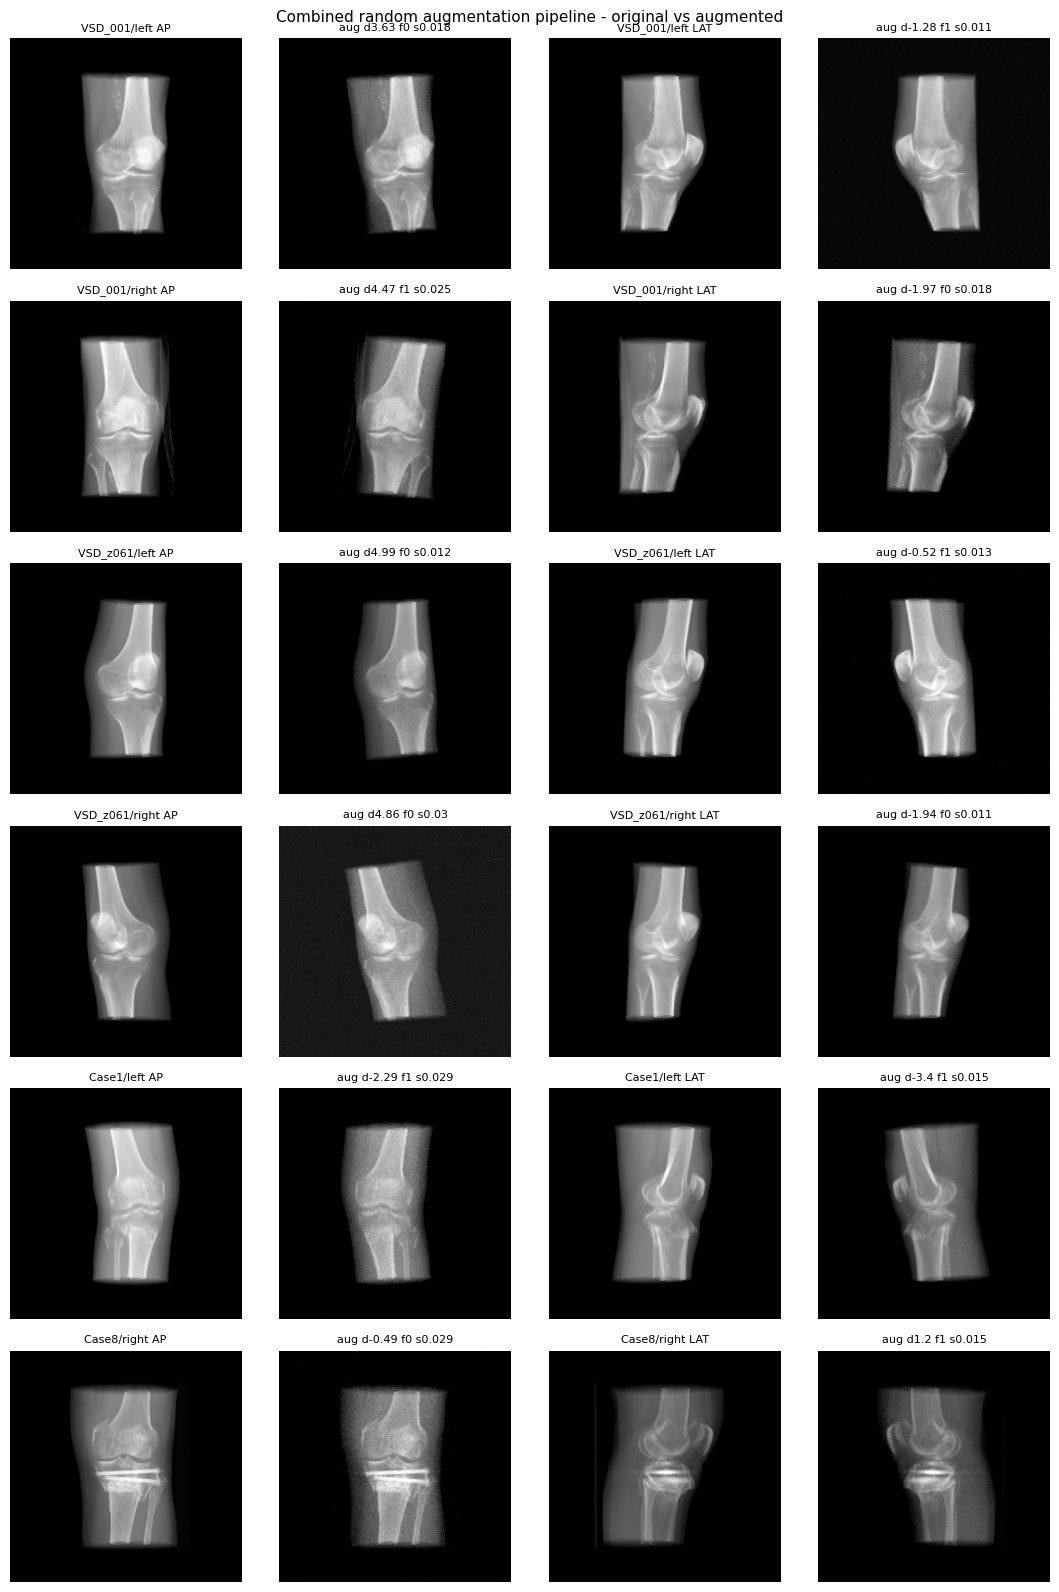

In [6]:
# One row per test knee: original vs augmented, for both AP and LAT.
n = len(TEST_CASES)
fig, axes = plt.subplots(n, 4, figsize=(11, 2.7 * n))
if n == 1:
    axes = axes[None, :]

for row, (dataset, case, side) in enumerate(TEST_CASES):
    ap, lat = load_pair(dataset, case, side)
    ap_aug,  p_ap  = augment_pipeline(ap,  rng)
    lat_aug, p_lat = augment_pipeline(lat, rng)
    panels = [
        (f"{case}/{side} AP", ap),
        (f"aug d{p_ap['deg']} f{int(p_ap['flip'])} s{p_ap['sigma']}", ap_aug),
        (f"{case}/{side} LAT", lat),
        (f"aug d{p_lat['deg']} f{int(p_lat['flip'])} s{p_lat['sigma']}", lat_aug),
    ]
    for col, (title, im) in enumerate(panels):
        ax = axes[row, col]
        ax.imshow(im, cmap="gray", vmin=0.0, vmax=1.0)
        ax.set_title(title, fontsize=8)
        ax.axis("off")
fig.suptitle("Combined random augmentation pipeline - original vs augmented", fontsize=11)
plt.tight_layout()
plt.show()

## 3. Variant definitions — full combinatorial grid

To maximize training permutations we save the **Cartesian product** of discrete
augmentation levels. Each dimension below contributes its levels; the saved variants are
every combination of (rotation x flip x noise x brightness-contrast), excluding the
pure-identity combination (which would just reproduce the original DRR).

Edit the `*_LEVELS` lists to grow or shrink the grid. A variant is tagged
`geometric=True` whenever flip is on or rotation != 0, so the training loader knows it must
apply the same transform to the 3D ground-truth volume.

In [7]:
# ---- Discrete augmentation levels (edit to grow/shrink the grid) ----
# Each level is (name, value). The batch saves the full Cartesian product of these.
FLIP_LEVELS  = [("noflip", False), ("flip", True)]            # 2
ROT_LEVELS   = [("rot0", 0.0), ("rotm5", -ROT_DEG), ("rotp5", +ROT_DEG)]  # 3
NOISE_LEVELS = [("noise0", 0.0), ("noise", 0.02)]            # 2
BC_LEVELS    = [("bc0", (0.0, 1.0)), ("brighten", (0.08, 1.1))]  # 2: (bright, contrast)


def _is_identity(flip, deg, sigma, bc):
    """True for the no-op combination (== the original DRR), which we skip."""
    return (not flip) and deg == 0.0 and sigma == 0.0 and bc == (0.0, 1.0)


def build_variants():
    """Full Cartesian product of the level lists, minus the pure-identity variant."""
    variants = []
    for (rn, deg), (fn, flip), (nn, sigma), (bn, bc) in itertools.product(
            ROT_LEVELS, FLIP_LEVELS, NOISE_LEVELS, BC_LEVELS):
        if _is_identity(flip, deg, sigma, bc):
            continue
        variants.append({
            "name": f"{rn}_{fn}_{nn}_{bn}",
            "deg": deg, "flip": flip, "sigma": sigma,
            "bright": bc[0], "contrast": bc[1],
            "geometric": bool(flip or deg != 0.0),
        })
    return variants


def make_variant(img: np.ndarray, v: dict, rng: np.random.Generator) -> np.ndarray:
    """Apply one variant spec to an image: geometric ops first, then photometric."""
    out = aug_rotate(img, v["deg"]) if v["deg"] != 0.0 else img
    if v["flip"]:
        out = aug_hflip(out)
    if v["sigma"] > 0.0:
        out = aug_gaussian_noise(out, v["sigma"], rng)
    if (v["bright"], v["contrast"]) != (0.0, 1.0):
        out = aug_brightness_contrast(out, v["bright"], v["contrast"])
    return _clip01(out)


def to_uint16(img01: np.ndarray) -> np.ndarray:
    """Encode a [0,1] float image as 16-bit PNG data (same as drr_generation.ipynb)."""
    return (np.clip(img01, 0.0, 1.0) * 65535.0).round().astype(np.uint16)


def save_variant(img01, dataset, case, side, variant, view, save_png=True):
    """Save one augmented view to augmented_DRRs/{dataset}/{case}/{side}/{variant}/{view}.*
    as .npy (float32 [0,1]) and, optionally, a 16-bit .png QA copy."""
    out_dir = AUG_OUT_DIR / dataset / case / side / variant
    out_dir.mkdir(parents=True, exist_ok=True)
    np.save(out_dir / f"{view}.npy", img01.astype(np.float32))
    if save_png:
        imageio.imwrite(out_dir / f"{view}.png", to_uint16(img01))


VARIANTS = build_variants()
n_geo = sum(v["geometric"] for v in VARIANTS)
logger.info(f"{len(VARIANTS)} variants/knee "
            f"({n_geo} geometric, {len(VARIANTS) - n_geo} photometric-only)")
print("variant names:")
for v in VARIANTS:
    print(f"  {v['name']:32} {'geometric' if v['geometric'] else 'photometric'}")

2026-06-06 16:01:19.147 | INFO     | __main__:<module>:59 - 23 variants/knee (20 geometric, 3 photometric-only)


variant names:
  rot0_noflip_noise0_brighten      photometric
  rot0_noflip_noise_bc0            photometric
  rot0_noflip_noise_brighten       photometric
  rot0_flip_noise0_bc0             geometric
  rot0_flip_noise0_brighten        geometric
  rot0_flip_noise_bc0              geometric
  rot0_flip_noise_brighten         geometric
  rotm5_noflip_noise0_bc0          geometric
  rotm5_noflip_noise0_brighten     geometric
  rotm5_noflip_noise_bc0           geometric
  rotm5_noflip_noise_brighten      geometric
  rotm5_flip_noise0_bc0            geometric
  rotm5_flip_noise0_brighten       geometric
  rotm5_flip_noise_bc0             geometric
  rotm5_flip_noise_brighten        geometric
  rotp5_noflip_noise0_bc0          geometric
  rotp5_noflip_noise0_brighten     geometric
  rotp5_noflip_noise_bc0           geometric
  rotp5_noflip_noise_brighten      geometric
  rotp5_flip_noise0_bc0            geometric
  rotp5_flip_noise0_brighten       geometric
  rotp5_flip_noise_bc0            

## 4. Batch processing — all cases x all variants

Generate the full combinatorial variant set for every knee in `data/interim/DRRs/`
(58 healthy + 14 fractured) and save under
`augmented_DRRs/{dataset}/{case}/{side}/{variant}/{ap,lat}.npy`. A fresh seeded RNG makes
the run reproducible, and the output directory is rebuilt from scratch so stale files from
earlier runs are removed.

`SAVE_PNG` defaults to `False`: the `.npy` is the model input, and saving a 16-bit PNG for
every variant roughly doubles the file count for QA copies that the visual-inspection cell
already renders from the `.npy`. Set it to `True` if you want PNG copies on disk too.

A metadata CSV records every saved variant pair and its augmentation parameters (including
the `geometric` flag).

In [8]:
import os, stat, time

SAVE_PNG = False   # also write 16-bit PNG copies per variant (True doubles the file count)


def robust_rmtree(path: Path, retries: int = 4, delay: float = 0.7):
    """Delete a tree on Windows/OneDrive where files may be read-only or briefly locked.
    Clears the read-only bit on error and retries; best-effort on the final attempt so a
    transient sync lock never crashes the batch (re-runs overwrite same-named files anyway)."""
    def _onerror(func, p, _exc):
        try:
            os.chmod(p, stat.S_IWRITE)
            func(p)
        except Exception:
            pass
    for _ in range(retries):
        if not path.exists():
            return
        try:
            shutil.rmtree(path, onerror=_onerror)
        except Exception:
            pass
        if not path.exists():
            return
        time.sleep(delay)
    if path.exists():
        shutil.rmtree(path, ignore_errors=True)  # final best-effort


# Fresh rebuild so prior outputs (e.g. earlier combined-only runs) don't linger.
robust_rmtree(AUG_OUT_DIR)
AUG_OUT_DIR.mkdir(parents=True, exist_ok=True)

# Independent seeded RNG so the batch is reproducible regardless of earlier cell runs.
batch_rng = np.random.default_rng(SEED)
all_cases = collect_all_cases(DRR_DIR)

n_pairs = len(all_cases) * len(VARIANTS)
n_files = n_pairs * 2 * (2 if SAVE_PNG else 1)
logger.info(f"{len(all_cases)} knees x {len(VARIANTS)} variants = {n_pairs} pairs "
            f"({n_pairs * 2} images, ~{n_files} files)")

rows = []
for dataset, case, side in tqdm(all_cases, desc="cases"):
    ap, lat = load_pair(dataset, case, side)
    for v in VARIANTS:
        ap_v  = make_variant(ap,  v, batch_rng)
        lat_v = make_variant(lat, v, batch_rng)
        save_variant(ap_v,  dataset, case, side, v["name"], "ap",  SAVE_PNG)
        save_variant(lat_v, dataset, case, side, v["name"], "lat", SAVE_PNG)
        rel = f"{dataset}/{case}/{side}/{v['name']}"
        rows.append({
            "dataset": dataset, "case": case, "side": side, "variant": v["name"],
            "deg": v["deg"], "flip": v["flip"], "sigma": v["sigma"],
            "bright": v["bright"], "contrast": v["contrast"], "geometric": v["geometric"],
            "ap_npy": f"{rel}/ap.npy", "lat_npy": f"{rel}/lat.npy",
        })

batch_df = pd.DataFrame(rows)
meta_path = AUG_OUT_DIR / "augmentation_variants_metadata.csv"
batch_df.to_csv(meta_path, index=False)

logger.info(f"saved {len(batch_df)} variant pairs ({len(batch_df) * 2} images) -> {AUG_OUT_DIR}")
logger.info(f"metadata -> {meta_path}")
print(batch_df.groupby(["dataset", "geometric"]).size().rename("pairs").to_string())

2026-06-06 16:01:19.267 | INFO     | __main__:<module>:40 - 72 knees x 23 variants = 1656 pairs (3312 images, ~3312 files)


cases:   0%|          | 0/72 [00:00<?, ?it/s]

cases:   1%|▏         | 1/72 [00:00<00:28,  2.45it/s]

cases:   3%|▎         | 2/72 [00:00<00:28,  2.43it/s]

cases:   4%|▍         | 3/72 [00:01<00:28,  2.39it/s]

...

cases: 100%|██████████| 72/72 [00:30<00:00,  2.48it/s]

cases: 100%|██████████| 72/72 [00:30<00:00,  2.38it/s]


2026-06-06 16:01:49.648 | INFO     | __main__:<module>:63 - saved 1656 variant pairs (3312 images) -> c:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject\data\processed\augmented_DRRs


2026-06-06 16:01:49.650 | INFO     | __main__:<module>:64 - metadata -> c:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject\data\processed\augmented_DRRs\augmentation_variants_metadata.csv


dataset    geometric
fractured  False          42
           True          280
healthy    False         174
           True         1160


## 5. Visual inspection — variant grid

For one healthy and one fractured knee, display the original AP alongside an evenly-spaced
selection of the saved variants so the augmentation grid can be eyeballed. Each panel is
loaded back from the saved `.npy`, so this also confirms the files on disk are readable.
Titles show the variant name. The figures are saved for offline review.

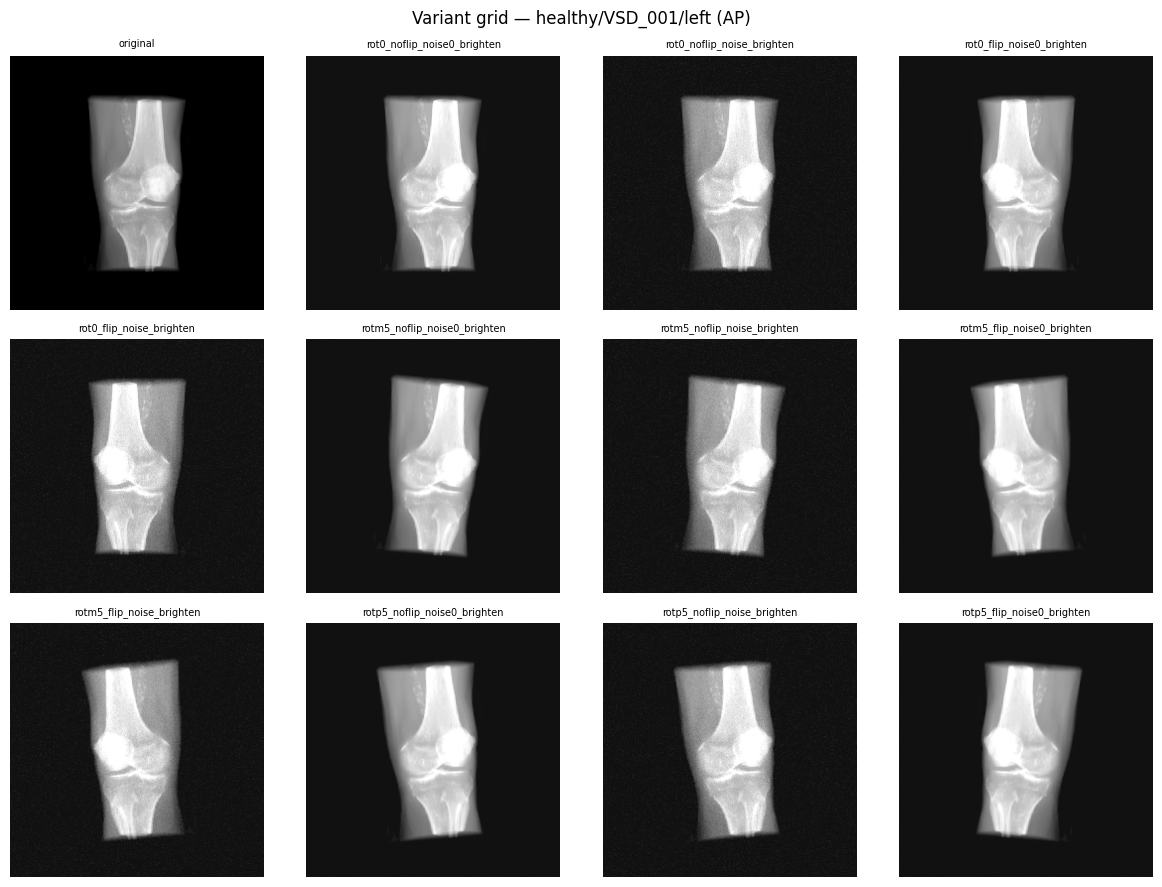

2026-06-06 16:01:53.014 | INFO     | __main__:<module>:38 - inspection figure saved -> c:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject\data\processed\augmented_DRRs\visual_inspection_healthy_VSD_001_left.png


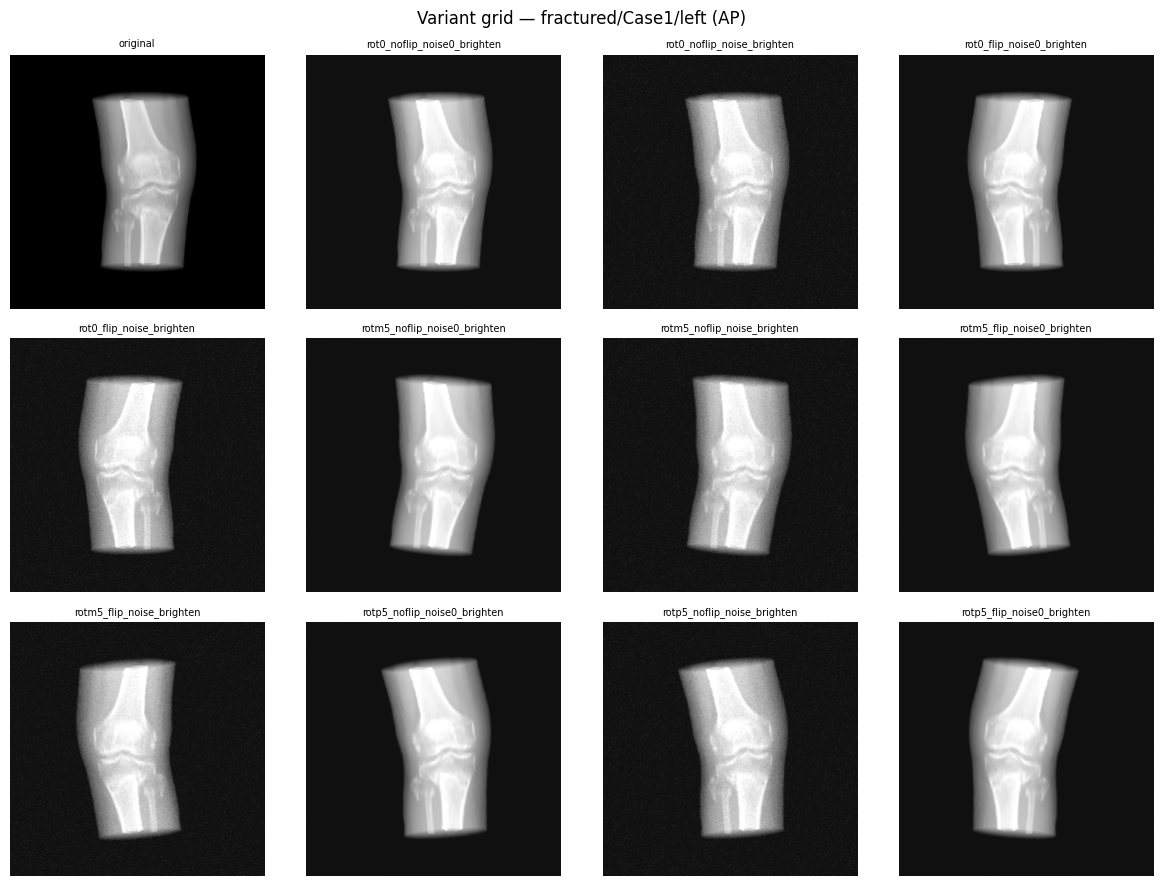

2026-06-06 16:01:56.236 | INFO     | __main__:<module>:38 - inspection figure saved -> c:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject\data\processed\augmented_DRRs\visual_inspection_fractured_Case1_left.png


In [9]:
def load_variant(dataset, case, side, variant, view="ap"):
    """Load a saved augmented view from augmented_DRRs/ (float32 [0,1])."""
    return np.load(AUG_OUT_DIR / dataset / case / side / variant / f"{view}.npy").astype(np.float32)


# One healthy + one fractured knee (first of each, if present).
INSPECT_CASES = []
for ds in ["healthy", "fractured"]:
    picks = [c for c in all_cases if c[0] == ds]
    if picks:
        INSPECT_CASES.append(picks[0])

SHOW_N = 11  # variants to show alongside the original
step   = max(1, len(VARIANTS) // SHOW_N)
sel    = VARIANTS[::step][:SHOW_N]

for dataset, case, side in INSPECT_CASES:
    ap_orig, _ = load_pair(dataset, case, side)
    panels = [("original", ap_orig)] + [
        (v["name"], load_variant(dataset, case, side, v["name"], "ap")) for v in sel
    ]
    ncol = 4
    nrow = int(np.ceil(len(panels) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(3 * ncol, 3 * nrow))
    axes = axes.ravel()
    for ax, (title, im) in zip(axes, panels):
        ax.imshow(im, cmap="gray", vmin=0.0, vmax=1.0)
        ax.set_title(title, fontsize=7)
        ax.axis("off")
    for ax in axes[len(panels):]:
        ax.axis("off")
    fig.suptitle(f"Variant grid — {dataset}/{case}/{side} (AP)", fontsize=12)
    plt.tight_layout()
    plt.show()

    insp_path = AUG_OUT_DIR / f"visual_inspection_{dataset}_{case}_{side}.png"
    fig.savefig(insp_path, dpi=150, bbox_inches="tight")
    logger.info(f"inspection figure saved -> {insp_path}")

## Sanity check — round-trip a saved variant

Reload one saved variant from disk and confirm the `.npy` (float32 `[0, 1]`) — and the
`.png` (uint16 `[0, 65535]`) if `SAVE_PNG` was on — round-trip correctly, and report the
total number of variant pairs written.

In [10]:
# Reload one saved variant and confirm the round-trip.
_row = batch_df.iloc[0]
_npy = AUG_OUT_DIR / _row["ap_npy"]
_a = np.load(_npy)
print(f".npy  {_row['ap_npy']}: dtype={_a.dtype} shape={_a.shape} "
      f"range=[{_a.min():.3f}, {_a.max():.3f}]")
if SAVE_PNG:
    _png = _npy.with_suffix(".png")
    _p = imageio.imread(_png)
    print(f".png  {_png.name}: dtype={_p.dtype} shape={_p.shape} "
          f"range=[{_p.min()}, {_p.max()}]")

print(f"\nvariants/knee : {len(VARIANTS)}")
print(f"knees         : {batch_df[['dataset','case','side']].drop_duplicates().shape[0]}")
print(f"variant pairs : {len(batch_df)}  ->  {len(batch_df) * 2} images on disk")

.npy  healthy/VSD_001/left/rot0_noflip_noise0_brighten/ap.npy: dtype=float32 shape=(256, 256) range=[0.067, 1.000]

variants/knee : 23
knees         : 72
variant pairs : 1656  ->  3312 images on disk
